In [ ]:
!pip install stumpy==1.1

  Attempting uninstall: stumpy
    Found existing installation: stumpy 1.13.0
    Uninstalling stumpy-1.13.0:
      Successfully uninstalled stumpy-1.13.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tsfresh 0.21.0 requires stumpy>=1.7.2, but you have stumpy 1.1.0 which is incompatible.


In [ ]:
!pip install tsfresh dtaidistance statsmodels


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 22.2 MB/s eta 0:00:00


🔄 Downloading stock data...


ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['HDFC.NS']: YFTzMissingError('possibly delisted; no timezone found')


Error loading HDFC.NS: No data for HDFC.NS
✅ Computing daily log returns...
📉 Applying EWMA (span=20)...
📊 Calculating Pearson correlation matrix...


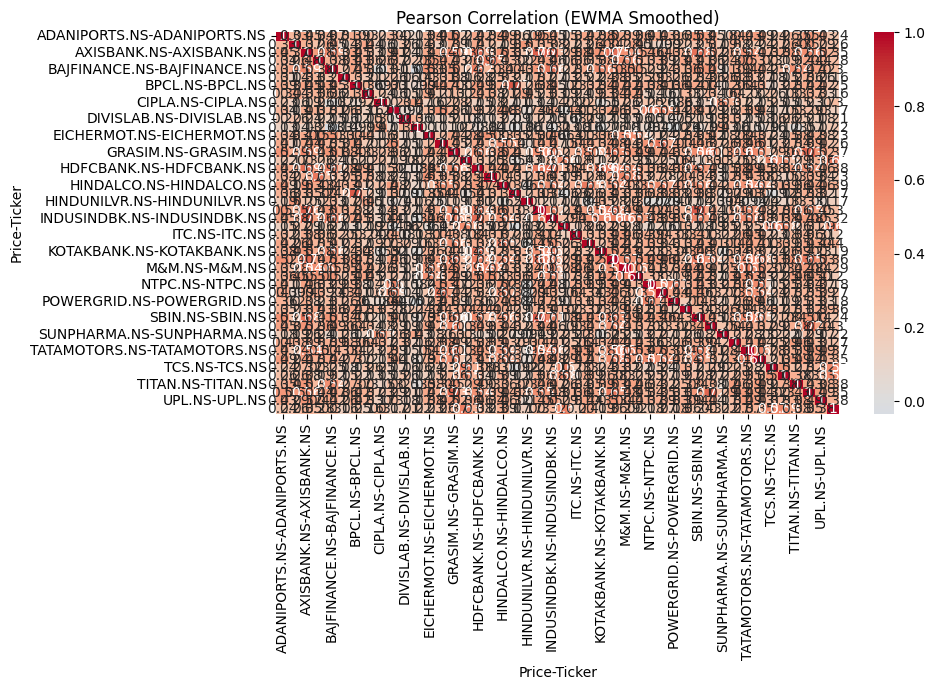

📐 Calculating Exponentially Weighted Similarity...


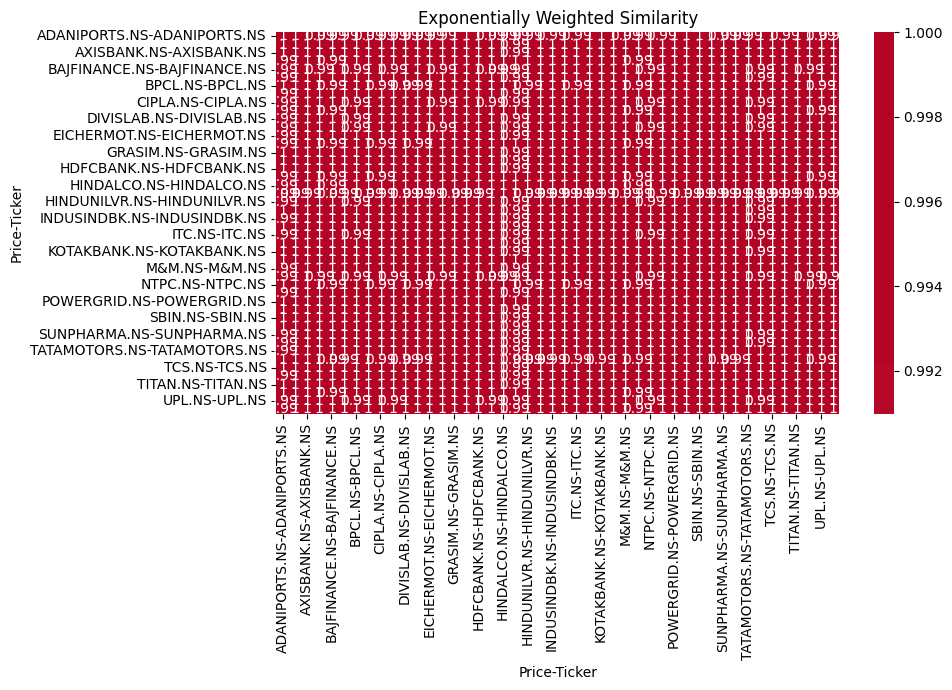

🔍 Top correlated stocks (EW Similarity)...
🧭 Calculating Movement Direction Similarity...


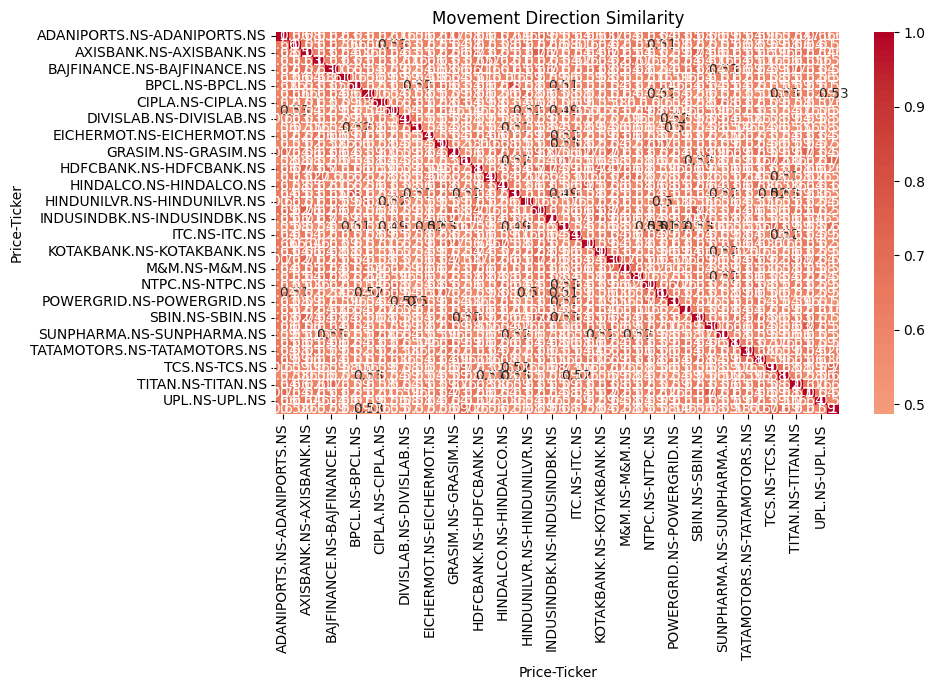

('ADANIPORTS.NS', 'ADANIPORTS.NS'): [('TATAPOWER.NS', 'TATAPOWER.NS'), ('NTPC.NS', 'NTPC.NS'), ('LT.NS', 'LT.NS')]
('ASIANPAINT.NS', 'ASIANPAINT.NS'): [('RELIANCE.NS', 'RELIANCE.NS'), ('KOTAKBANK.NS', 'KOTAKBANK.NS'), ('HDFCBANK.NS', 'HDFCBANK.NS')]
('AXISBANK.NS', 'AXISBANK.NS'): [('ICICIBANK.NS', 'ICICIBANK.NS'), ('SHREECEM.NS', 'SHREECEM.NS'), ('GRASIM.NS', 'GRASIM.NS')]
('BAJAJ-AUTO.NS', 'BAJAJ-AUTO.NS'): [('HEROMOTOCO.NS', 'HEROMOTOCO.NS'), ('ULTRACEMCO.NS', 'ULTRACEMCO.NS'), ('COALINDIA.NS', 'COALINDIA.NS')]
('BAJFINANCE.NS', 'BAJFINANCE.NS'): [('UPL.NS', 'UPL.NS'), ('ITC.NS', 'ITC.NS'), ('MARUTI.NS', 'MARUTI.NS')]
('BHARTIARTL.NS', 'BHARTIARTL.NS'): [('DRREDDY.NS', 'DRREDDY.NS'), ('SUNPHARMA.NS', 'SUNPHARMA.NS'), ('GRASIM.NS', 'GRASIM.NS')]
('BPCL.NS', 'BPCL.NS'): [('HEROMOTOCO.NS', 'HEROMOTOCO.NS'), ('HINDPETRO.NS', 'HINDPETRO.NS'), ('POWERGRID.NS', 'POWERGRID.NS')]
('BRITANNIA.NS', 'BRITANNIA.NS'): [('TATACONSUM.NS', 'TATACONSUM.NS'), ('KOTAKBANK.NS', 'KOTAKBANK.NS'), ('ONGC.N

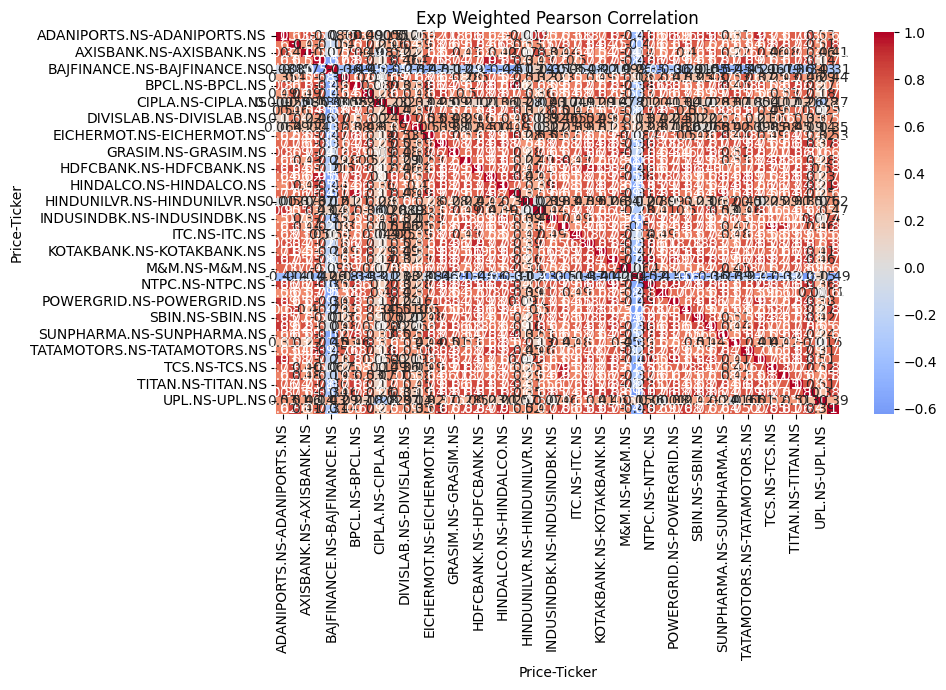

🧭 Calculating Exp Cosine Similarity...


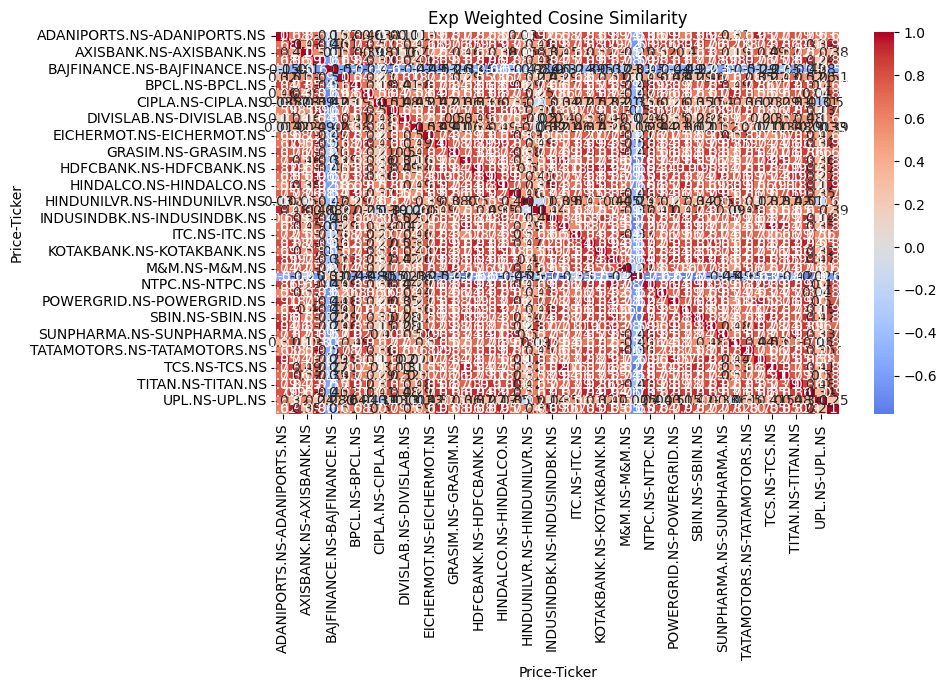

🌌 Calculating Gaussian Similarity...


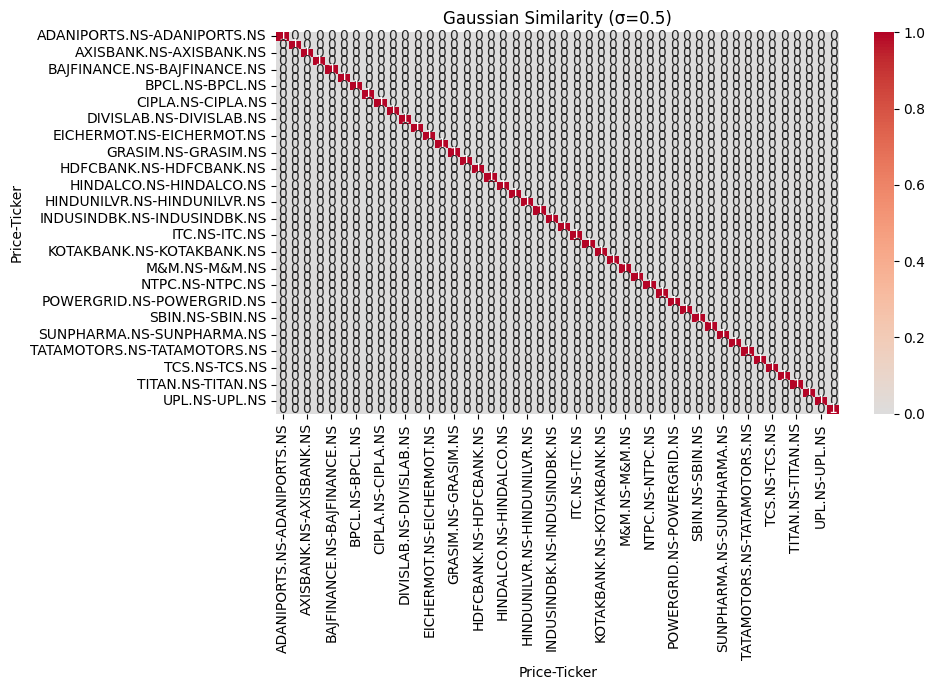

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
# ---- Configuration ---- #
tickers =  [
    'ADANIPORTS.NS', 'ASIANPAINT.NS', 'AXISBANK.NS', 'BAJAJ-AUTO.NS', 'BAJFINANCE.NS',
    'BHARTIARTL.NS', 'BPCL.NS', 'BRITANNIA.NS', 'CIPLA.NS', 'COALINDIA.NS',
    'DIVISLAB.NS', 'DRREDDY.NS', 'EICHERMOT.NS', 'GAIL.NS', 'GRASIM.NS',
    'HCLTECH.NS', 'HDFCBANK.NS', 'HDFC.NS', 'HEROMOTOCO.NS', 'HINDALCO.NS',
    'HINDPETRO.NS', 'HINDUNILVR.NS', 'ICICIBANK.NS', 'INDUSINDBK.NS', 'INFY.NS',
    'ITC.NS', 'JSWSTEEL.NS', 'KOTAKBANK.NS', 'LT.NS', 'M&M.NS', 'MARUTI.NS',
    'NTPC.NS', 'ONGC.NS', 'POWERGRID.NS', 'RELIANCE.NS', 'SBIN.NS', 'SHREECEM.NS',
    'SUNPHARMA.NS', 'TATACONSUM.NS', 'TATAMOTORS.NS', 'TATAPOWER.NS', 'TCS.NS',
    'TECHM.NS', 'TITAN.NS', 'ULTRACEMCO.NS', 'UPL.NS', 'WIPRO.NS'
]
# tickers =  [
#      'AXISBANK.NS', 'HDFCBANK.NS', 'ICICIBANK.NS', 'INDUSINDBK.NS'

# ]
start_date = "2015-01-01"
end_date = "2023-12-31"
ewm_span = 20
exp_alpha = 0.95  # Exponential weight decay for similarity

# ---- Step 1: Download & preprocess stock data ---- #
def get_stock_data(ticker):
    df = yf.download(ticker, start=start_date, end=end_date, auto_adjust=True, progress=False)
    if df.empty:
        raise ValueError(f"No data for {ticker}")
    df = df[['Close']]
    df.rename(columns={'Close': ticker}, inplace=True)
    return df

def combine_all_stocks(tickers):
    combined_df = pd.DataFrame()
    for ticker in tickers:
        try:
            df = get_stock_data(ticker)
            if combined_df.empty:
                combined_df = df
            else:
                combined_df = combined_df.join(df, how='outer')
        except Exception as e:
            print(f"Error loading {ticker}: {e}")
    return combined_df.dropna()
# ---- Step 2: Compute Daily Log Returns ---- #
def compute_log_returns(df):
    return np.log(df / df.shift(1)).dropna()
# ---- Step 3: Apply EWMA smoothing ---- #
def apply_ewm(df, span=20):
    return df.ewm(span=span).mean()
# ---- Step 4: Compute Correlation Matrix ---- #
def compute_correlation(df):
    return df.corr()

# ---- Step 5: Plot Heatmap ---- #
def plot_heatmap(corr_matrix, title="EWMA Smoothed Return Correlation"):
    plt.figure(figsize=(10, 7))
    sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0)
    plt.title(title)
    plt.tight_layout()
    plt.show()

# ---- Step 6: Exponential Weighting Similarity ---- #
def weighted_similarity_matrix(df, alpha=0.85):
    n = df.shape[0]
    weights = np.array([alpha**(n - i - 1) for i in range(n)])
    weights /= weights.sum()  # Normalize
    similarity = pd.DataFrame(index=df.columns, columns=df.columns)
    for stock1 in df.columns:
        for stock2 in df.columns:
            diff=  df[stock1]-df[stock2]
            score= np.dot(weights,1-np.abs(diff))   # 1 - abs diff gives similarity
            similarity.loc[stock1, stock2] = score
    return similarity.astype(float)



# ---- Step 7: Rank Top Correlated ---- #
def get_top_correlated(corr_df, top_k=3):
    top_map = {}
    for stock in corr_df.columns:
        top_map[stock] = corr_df[stock].drop(stock).sort_values(ascending=False).head(top_k).index.tolist()
    return top_map
def exp_pearson_corr(df, alpha=0.95):
    n = df.shape[0]
    weights = np.array([alpha ** (n - i - 1) for i in range(n)])
    weights /= weights.sum()

    weighted_corr = pd.DataFrame(index=df.columns, columns=df.columns)
    for i in df.columns:
        for j in df.columns:
            x = df[i] - df[i].mean()
            y = df[j] - df[j].mean()
            numerator = np.sum(weights * x * y)
            denominator = np.sqrt(np.sum(weights * x**2)) * np.sqrt(np.sum(weights * y**2))
            weighted_corr.loc[i, j] = numerator / denominator
    return weighted_corr.astype(float)

# -- Method 2: Exponential Cosine Similarity --
def exp_cosine_similarity(df, alpha=0.95):
    n = df.shape[0]
    weights = np.array([alpha ** (n - i - 1) for i in range(n)])
    weights /= weights.sum()

    weighted_df = df.multiply(weights, axis=0)
    cos_sim = cosine_similarity(weighted_df.T)
    return pd.DataFrame(cos_sim, index=df.columns, columns=df.columns)

# -- Method 3: Gaussian Similarity --
def gaussian_similarity(df, sigma=1.0):
    sim_df = pd.DataFrame(index=df.columns, columns=df.columns)
    for stock1 in df.columns:
        for stock2 in df.columns:
            diff = df[stock1] - df[stock2]
            dist = np.linalg.norm(diff)
            sim = np.exp(-dist**2 / (2 * sigma**2))
            sim_df.loc[stock1, stock2] = sim
    return sim_df.astype(float)

def movement_direction_similarity(df):
    sim_df = pd.DataFrame(index=df.columns, columns=df.columns)
    signs = np.sign(df)  # +1 if up, -1 if down
    for stock1 in df.columns:
        for stock2 in df.columns:
            sim = np.mean(signs[stock1] == signs[stock2])
            sim_df.loc[stock1, stock2] = sim
    return sim_df.astype(float)

# Required installations for DTW, TSFresh, and ARIMA
# These would normally be run via pip install if not already present:
# !pip install tsfresh
# !pip install dtaidistance
# !pip install statsmodels

import pandas as pd
import numpy as np
# from tsfresh.feature_extraction import extract_features
# from tsfresh.utilities.dataframe_functions import make_forecasting_frame
from dtaidistance import dtw
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import entropy
from statsmodels.tsa.arima.model import ARIMA

# Placeholder for stock returns
# Assuming 'ewm_returns' is already defined in the main script as per your original code.
from statsmodels.tsa.stattools import coint

def compute_cointegration_similarity(data: pd.DataFrame):
    stocks = data.columns
    n = len(stocks)
    coint_matrix = np.zeros((n, n))

    for i in range(n):
        for j in range(n):
            if i < j:
                score, pvalue, _ = coint(data.iloc[:, i], data.iloc[:, j])
                sim = 1 - pvalue  # Higher p-value = less similar
                coint_matrix[i, j] = sim
                coint_matrix[j, i] = sim
            elif i == j:
                coint_matrix[i, j] = 1.0

    return pd.DataFrame(coint_matrix, index=stocks, columns=stocks)

# --- DTW Similarity --- #
from dtaidistance import dtw
import numpy as np
import pandas as pd
def compute_dtw_similarity(data: pd.DataFrame):
    from dtaidistance import dtw

    stocks = data.columns
    n = len(stocks)
    dtw_matrix = np.zeros((n, n))

    for i in range(n):
        for j in range(i, n):
            dist = dtw.distance(data.iloc[:, i], data.iloc[:, j])
            dtw_matrix[i, j] = dist
            dtw_matrix[j, i] = dist

    return pd.DataFrame(dtw_matrix, index=stocks, columns=stocks)


# --- TSFresh Shape-based Cosine Similarity --- #
# from tsfresh import extract_features
# from tsfresh.utilities.dataframe_functions import impute
# from tsfresh.utilities.dataframe_functions import make_forecasting_frame
# from sklearn.metrics.pairwise import cosine_similarity

# def compute_tsfresh_cosine_similarity(df, rolling_window=50):
#     features_list = []
#     ids = []

#     for stock in df.columns:
#         try:
#             timeseries = df[stock]
#             df_fc, y = make_forecasting_frame(timeseries, kind="price", max_timeshift=rolling_window, rolling_direction=1)

#             features = extract_features(df_fc, column_id="id", column_sort="time", disable_progressbar=True)

#             # Optional: impute missing values
#             impute(features)

#             # Filter only numeric columns
#             features = features.select_dtypes(include=[np.number])

#             # Drop columns that are completely NaN
#             features = features.dropna(axis=1, how='all')

#             if features.shape[1] == 0:
#                 print(f"⚠️ Skipping {stock}: no valid numeric features.")
#                 continue

#             # Take mean of each feature column
#             feature_vector = features.mean().values

#             # Add to list
#             features_list.append(feature_vector)
#             ids.append(stock)

#         except Exception as e:
#             print(f"❌ Error processing {stock}: {e}")
#             continue

#     if len(features_list) < 2:
#         raise ValueError("Not enough valid time series for similarity computation.")

#     feature_matrix = np.vstack(features_list)
#     cosine_sim = cosine_similarity(feature_matrix)

#     return pd.DataFrame(cosine_sim, index=ids, columns=ids)


# --- KL Divergence Similarity (symmetric) --- #
def compute_kl_similarity(df, bins=100):
    stocks = df.columns
    kl_sim_matrix = pd.DataFrame(index=stocks, columns=stocks, dtype=float)
    for i in stocks:
        for j in stocks:
            p = np.histogram(df[i], bins=bins, density=True)[0] + 1e-8
            q = np.histogram(df[j], bins=bins, density=True)[0] + 1e-8
            sim = -0.5 * (entropy(p, q) + entropy(q, p))  # symmetric KL divergence
            kl_sim_matrix.loc[i, j] = sim
    return kl_sim_matrix

# --- Forecast Distance using ARIMA --- #
def compute_forecast_distance(df, steps_ahead=5):
    error_matrix = pd.DataFrame(index=df.columns, columns=df.columns, dtype=float)
    forecast_errors = {}

    for stock in df.columns:
        series = df[stock]
        try:
            model = ARIMA(series, order=(1,1,1))
            model_fit = model.fit()
            forecast = model_fit.forecast(steps=steps_ahead)
            actual = series[-steps_ahead:].values
            error = np.mean(np.abs(forecast - actual))
        except:
            error = np.inf
        forecast_errors[stock] = error

    for i in df.columns:
        for j in df.columns:
            dist = np.abs(forecast_errors[i] - forecast_errors[j])
            sim = np.exp(-dist)
            error_matrix.loc[i, j] = sim
    return error_matrix

# Now we define the entry points for these methods to be run with your main dataset.


# ---- Main Execution ---- #

if __name__ == "__main__":
    print("🔄 Downloading stock data...")
    price_df = combine_all_stocks(tickers)
    print("✅ Computing daily log returns...")
    log_returns = compute_log_returns(price_df)
    print(f"📉 Applying EWMA (span={ewm_span})...")
    ewm_returns = apply_ewm(log_returns, span=ewm_span)
    print("📊 Calculating Pearson correlation matrix...")
    correlation_matrix = compute_correlation(ewm_returns)
    plot_heatmap(correlation_matrix, title="Pearson Correlation (EWMA Smoothed)")
    print("📐 Calculating Exponentially Weighted Similarity...")
    exp_sim_matrix = weighted_similarity_matrix(ewm_returns, alpha=exp_alpha)
    plot_heatmap(exp_sim_matrix, title="Exponentially Weighted Similarity")
    print("🔍 Top correlated stocks (EW Similarity)...")
    top_corr_map = get_top_correlated(exp_sim_matrix)
    print("🧭 Calculating Movement Direction Similarity...")
    movement_sim = movement_direction_similarity(ewm_returns)
    plot_heatmap(movement_sim, title="Movement Direction Similarity")


    for stock, top_stocks in top_corr_map.items():
        print(f"{stock}: {top_stocks}")
# Optional: Normalize with Z-score before advanced similarity
    normalized_returns = (ewm_returns - ewm_returns.mean()) / ewm_returns.std()

    # Exponential Pearson
    print("📐 Calculating Exponential Pearson Correlation...")
    exp_pearson = exp_pearson_corr(normalized_returns, alpha=exp_alpha)
    plot_heatmap(exp_pearson, title="Exp Weighted Pearson Correlation")

    # Exponential Cosine
    print("🧭 Calculating Exp Cosine Similarity...")
    exp_cosine = exp_cosine_similarity(normalized_returns, alpha=exp_alpha)
    plot_heatmap(exp_cosine, title="Exp Weighted Cosine Similarity")

    # Gaussian
    print("🌌 Calculating Gaussian Similarity...")
    gaussian_sim = gaussian_similarity(normalized_returns, sigma=0.5)
    plot_heatmap(gaussian_sim, title="Gaussian Similarity (σ=0.5)")
    # DTW Similarity
    # print("⏱️ Calculating DTW Similarity...")
    # dtw_similarity = compute_dtw_similarity(normalized_returns)
    # plot_heatmap(dtw_similarity, title="DTW-Based Similarity")

    # TSFresh + Cosine Similarity
    # print("🧬 Calculating TSFresh + Cosine Shape Similarity...")
    # tsfresh_cosine = compute_tsfresh_cosine_similarity(normalized_returns)
    # plot_heatmap(tsfresh_cosine, title="TSFresh + Cosine Shape Similarity")

    # # KL Divergence Similarity
    # print("📉 Calculating KL Divergence-Based Similarity...")
    # kl_sim = compute_kl_similarity(normalized_returns)
    # plot_heatmap(kl_sim, title="KL Divergence Similarity")

    # # Forecast Distance Similarity
    # print("🔮 Calculating Forecast Distance (ARIMA Error-Based)...")
    # forecast_sim = compute_forecast_distance(normalized_returns)
    # plot_heatmap(forecast_sim, title="Forecast Distance Similarity (ARIMA Error)")
    # dtw_sim_matrix = compute_dtw_similarity(normalized_returns)
    # plot_heatmap(dtw_sim_matrix, title="DTW Similarity")
    # coint_sim_matrix = compute_cointegration_similarity(normalized_returns)
    # plot_heatmap(coint_sim_matrix, title="Cointegration Similarity")

In [ ]:
def similarity_to_distance(sim_matrix):
    # Similarity (1 = perfect) → Distance (0 = perfect)
    dist = 1 - sim_matrix
    np.fill_diagonal(dist.values, 0.0)  # ensure diagonals are 0
    return dist

from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

def cluster_and_plot(sim_matrix, method_name="Similarity", n_clusters=3):
    sim_matrix = sim_matrix.astype(float)

    # Fix index if it's accidentally tuples
    sim_matrix.index = [str(i) for i in sim_matrix.index]
    sim_matrix.columns = [str(i) for i in sim_matrix.columns]

    # Convert similarity to distance
    distance_matrix = 1 - sim_matrix

    # Convert to condensed form (upper triangle, no diagonal)
    condensed_dist = squareform(distance_matrix.values, checks=False)

    # Perform linkage
    linkage_matrix = linkage(condensed_dist, method='ward')

    # Plot dendrogram
    plt.figure(figsize=(10, 6))
    dendrogram(
        linkage_matrix,
        labels=sim_matrix.columns,
        leaf_rotation=90,
        leaf_font_size=10,
        color_threshold=None
    )
    plt.title(f"Dendrogram using {method_name}")
    plt.ylabel("Distance")
    plt.tight_layout()
    plt.show()

    # Agglomerative clustering
    model = AgglomerativeClustering(n_clusters=n_clusters, metric='euclidean', linkage='ward')
    labels = model.fit_predict(distance_matrix)

    clusters = {stock: f"Cluster {label}" for stock, label in zip(sim_matrix.columns, labels)}
    print(f"\n📦 Cluster assignment for {method_name}:")
    for stock, group in clusters.items():
        print(f"{stock} ➤ {group}")


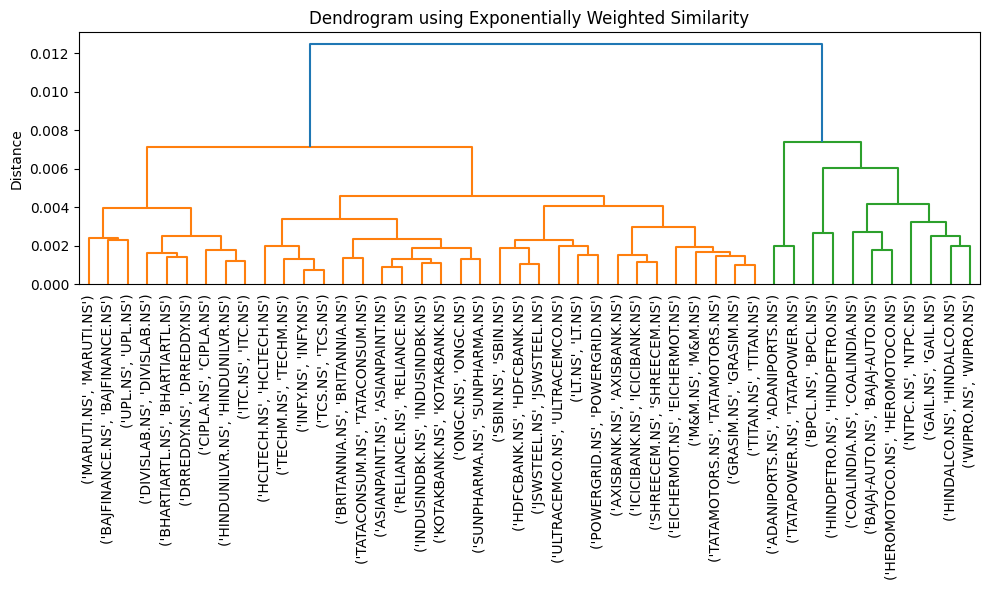

/usr/local/lib/python3.11/dist-packages/scipy/cluster/hierarchy.py:796: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  return linkage(y, method='ward', metric='euclidean')



📦 Cluster assignment for Exponentially Weighted Similarity:
('ADANIPORTS.NS', 'ADANIPORTS.NS') ➤ Cluster 1
('ASIANPAINT.NS', 'ASIANPAINT.NS') ➤ Cluster 0
('AXISBANK.NS', 'AXISBANK.NS') ➤ Cluster 0
('BAJAJ-AUTO.NS', 'BAJAJ-AUTO.NS') ➤ Cluster 2
('BAJFINANCE.NS', 'BAJFINANCE.NS') ➤ Cluster 0
('BHARTIARTL.NS', 'BHARTIARTL.NS') ➤ Cluster 0
('BPCL.NS', 'BPCL.NS') ➤ Cluster 2
('BRITANNIA.NS', 'BRITANNIA.NS') ➤ Cluster 0
('CIPLA.NS', 'CIPLA.NS') ➤ Cluster 0
('COALINDIA.NS', 'COALINDIA.NS') ➤ Cluster 2
('DIVISLAB.NS', 'DIVISLAB.NS') ➤ Cluster 0
('DRREDDY.NS', 'DRREDDY.NS') ➤ Cluster 0
('EICHERMOT.NS', 'EICHERMOT.NS') ➤ Cluster 0
('GAIL.NS', 'GAIL.NS') ➤ Cluster 2
('GRASIM.NS', 'GRASIM.NS') ➤ Cluster 0
('HCLTECH.NS', 'HCLTECH.NS') ➤ Cluster 0
('HDFCBANK.NS', 'HDFCBANK.NS') ➤ Cluster 0
('HEROMOTOCO.NS', 'HEROMOTOCO.NS') ➤ Cluster 2
('HINDALCO.NS', 'HINDALCO.NS') ➤ Cluster 2
('HINDPETRO.NS', 'HINDPETRO.NS') ➤ Cluster 1
('HINDUNILVR.NS', 'HINDUNILVR.NS') ➤ Cluster 0
('ICICIBANK.NS', 'ICICIBANK.NS

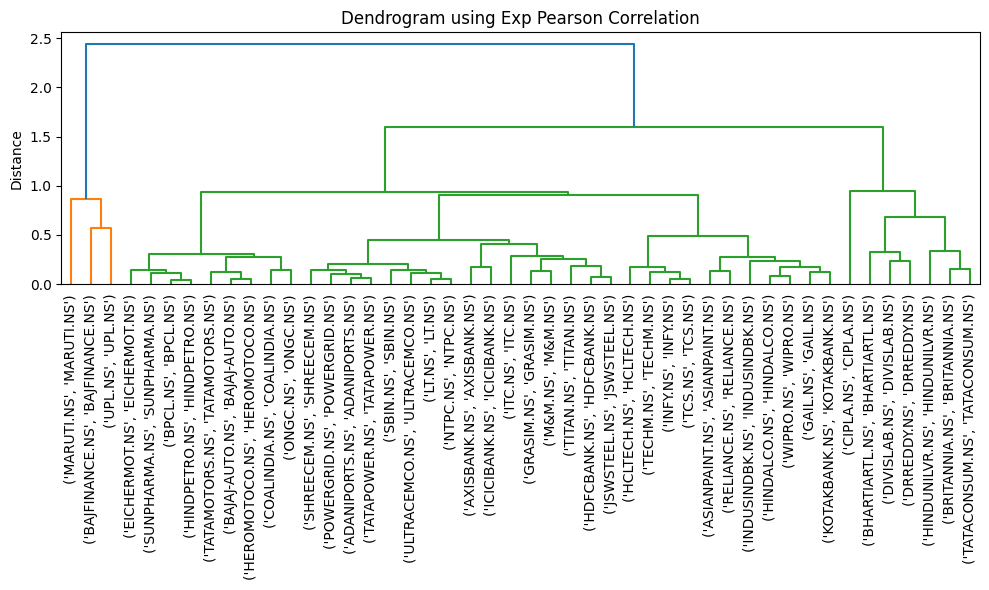


📦 Cluster assignment for Exp Pearson Correlation:
('ADANIPORTS.NS', 'ADANIPORTS.NS') ➤ Cluster 0
('ASIANPAINT.NS', 'ASIANPAINT.NS') ➤ Cluster 0
('AXISBANK.NS', 'AXISBANK.NS') ➤ Cluster 0
('BAJAJ-AUTO.NS', 'BAJAJ-AUTO.NS') ➤ Cluster 0
('BAJFINANCE.NS', 'BAJFINANCE.NS') ➤ Cluster 1
('BHARTIARTL.NS', 'BHARTIARTL.NS') ➤ Cluster 0
('BPCL.NS', 'BPCL.NS') ➤ Cluster 0
('BRITANNIA.NS', 'BRITANNIA.NS') ➤ Cluster 0
('CIPLA.NS', 'CIPLA.NS') ➤ Cluster 2
('COALINDIA.NS', 'COALINDIA.NS') ➤ Cluster 0
('DIVISLAB.NS', 'DIVISLAB.NS') ➤ Cluster 2
('DRREDDY.NS', 'DRREDDY.NS') ➤ Cluster 2
('EICHERMOT.NS', 'EICHERMOT.NS') ➤ Cluster 0
('GAIL.NS', 'GAIL.NS') ➤ Cluster 0
('GRASIM.NS', 'GRASIM.NS') ➤ Cluster 0
('HCLTECH.NS', 'HCLTECH.NS') ➤ Cluster 0
('HDFCBANK.NS', 'HDFCBANK.NS') ➤ Cluster 0
('HEROMOTOCO.NS', 'HEROMOTOCO.NS') ➤ Cluster 0
('HINDALCO.NS', 'HINDALCO.NS') ➤ Cluster 0
('HINDPETRO.NS', 'HINDPETRO.NS') ➤ Cluster 0
('HINDUNILVR.NS', 'HINDUNILVR.NS') ➤ Cluster 2
('ICICIBANK.NS', 'ICICIBANK.NS') ➤ Clust

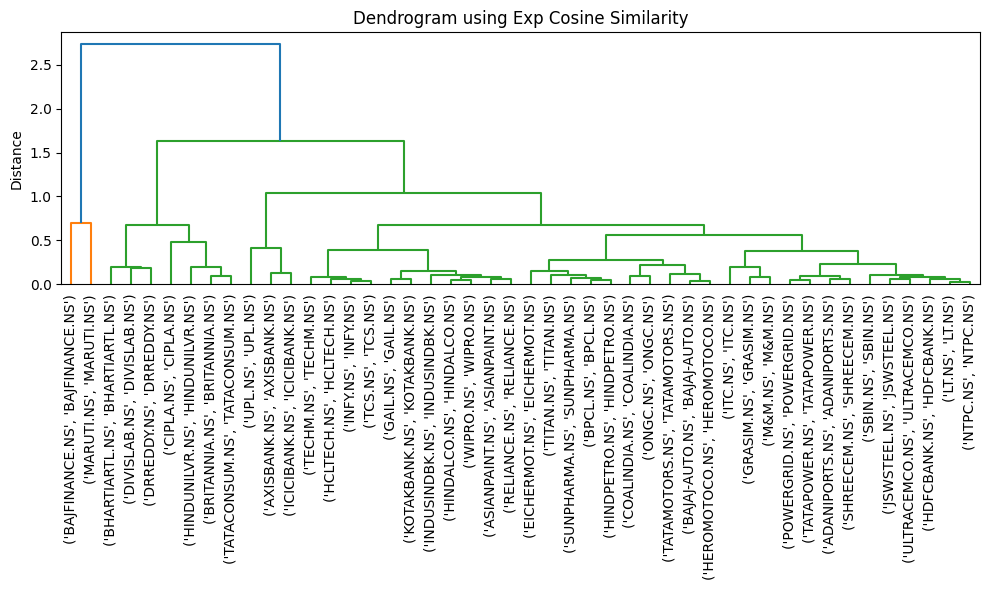


📦 Cluster assignment for Exp Cosine Similarity:
('ADANIPORTS.NS', 'ADANIPORTS.NS') ➤ Cluster 2
('ASIANPAINT.NS', 'ASIANPAINT.NS') ➤ Cluster 2
('AXISBANK.NS', 'AXISBANK.NS') ➤ Cluster 0
('BAJAJ-AUTO.NS', 'BAJAJ-AUTO.NS') ➤ Cluster 2
('BAJFINANCE.NS', 'BAJFINANCE.NS') ➤ Cluster 1
('BHARTIARTL.NS', 'BHARTIARTL.NS') ➤ Cluster 0
('BPCL.NS', 'BPCL.NS') ➤ Cluster 2
('BRITANNIA.NS', 'BRITANNIA.NS') ➤ Cluster 2
('CIPLA.NS', 'CIPLA.NS') ➤ Cluster 0
('COALINDIA.NS', 'COALINDIA.NS') ➤ Cluster 2
('DIVISLAB.NS', 'DIVISLAB.NS') ➤ Cluster 0
('DRREDDY.NS', 'DRREDDY.NS') ➤ Cluster 0
('EICHERMOT.NS', 'EICHERMOT.NS') ➤ Cluster 2
('GAIL.NS', 'GAIL.NS') ➤ Cluster 2
('GRASIM.NS', 'GRASIM.NS') ➤ Cluster 2
('HCLTECH.NS', 'HCLTECH.NS') ➤ Cluster 2
('HDFCBANK.NS', 'HDFCBANK.NS') ➤ Cluster 2
('HEROMOTOCO.NS', 'HEROMOTOCO.NS') ➤ Cluster 2
('HINDALCO.NS', 'HINDALCO.NS') ➤ Cluster 2
('HINDPETRO.NS', 'HINDPETRO.NS') ➤ Cluster 2
('HINDUNILVR.NS', 'HINDUNILVR.NS') ➤ Cluster 0
('ICICIBANK.NS', 'ICICIBANK.NS') ➤ Cluster

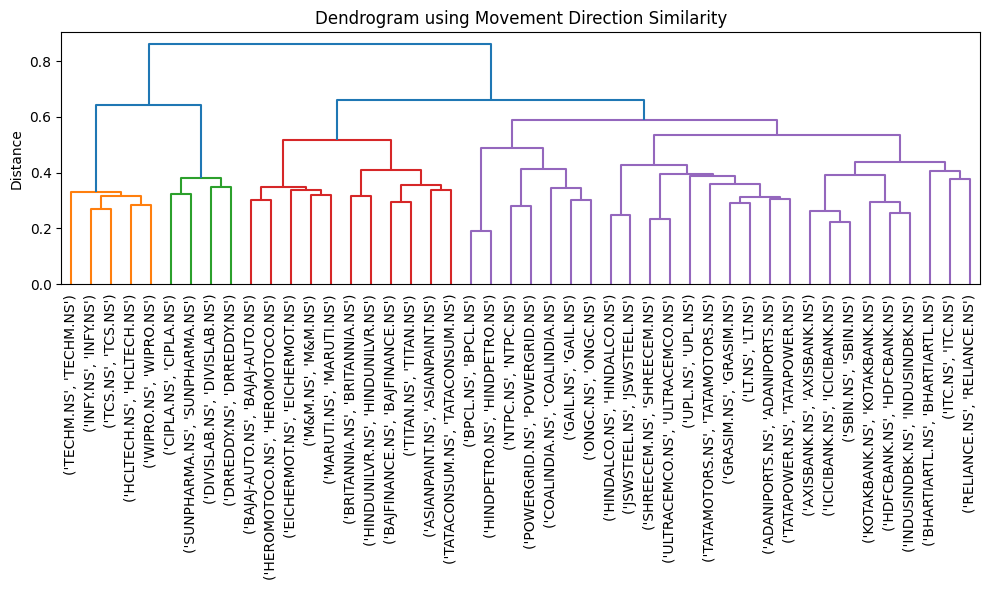


📦 Cluster assignment for Movement Direction Similarity:
('ADANIPORTS.NS', 'ADANIPORTS.NS') ➤ Cluster 0
('ASIANPAINT.NS', 'ASIANPAINT.NS') ➤ Cluster 2
('AXISBANK.NS', 'AXISBANK.NS') ➤ Cluster 0
('BAJAJ-AUTO.NS', 'BAJAJ-AUTO.NS') ➤ Cluster 2
('BAJFINANCE.NS', 'BAJFINANCE.NS') ➤ Cluster 2
('BHARTIARTL.NS', 'BHARTIARTL.NS') ➤ Cluster 2
('BPCL.NS', 'BPCL.NS') ➤ Cluster 0
('BRITANNIA.NS', 'BRITANNIA.NS') ➤ Cluster 2
('CIPLA.NS', 'CIPLA.NS') ➤ Cluster 1
('COALINDIA.NS', 'COALINDIA.NS') ➤ Cluster 0
('DIVISLAB.NS', 'DIVISLAB.NS') ➤ Cluster 1
('DRREDDY.NS', 'DRREDDY.NS') ➤ Cluster 1
('EICHERMOT.NS', 'EICHERMOT.NS') ➤ Cluster 2
('GAIL.NS', 'GAIL.NS') ➤ Cluster 0
('GRASIM.NS', 'GRASIM.NS') ➤ Cluster 0
('HCLTECH.NS', 'HCLTECH.NS') ➤ Cluster 1
('HDFCBANK.NS', 'HDFCBANK.NS') ➤ Cluster 2
('HEROMOTOCO.NS', 'HEROMOTOCO.NS') ➤ Cluster 2
('HINDALCO.NS', 'HINDALCO.NS') ➤ Cluster 0
('HINDPETRO.NS', 'HINDPETRO.NS') ➤ Cluster 0
('HINDUNILVR.NS', 'HINDUNILVR.NS') ➤ Cluster 2
('ICICIBANK.NS', 'ICICIBANK.NS') ➤

/usr/local/lib/python3.11/dist-packages/scipy/cluster/hierarchy.py:796: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  return linkage(y, method='ward', metric='euclidean')


In [ ]:

#Run clustering on each similarity metric
cluster_and_plot(exp_sim_matrix, method_name="Exponentially Weighted Similarity")
cluster_and_plot(exp_pearson, method_name="Exp Pearson Correlation")
cluster_and_plot(exp_cosine, method_name="Exp Cosine Similarity")
# cluster_and_plot(gaussian_sim, method_name="Gaussian Similarity")
cluster_and_plot(movement_sim, method_name="Movement Direction Similarity")
# cluster_and_plot(forecast_sim, method_name="Forecast Distance Similarity (ARIMA Error)")
# # cluster_and_plot(rolling_cosine, method_name="Rolling Cosine Similarity")
# # cluster_and_plot(tsfresh_cosine, method_name="TSFresh + Cosine Similarity")
# # cluster_and_plot(tsfresh_dtw, method_name="TSFresh + DTW Similarity")
# # cluster_and_plot(dtw_similarity_matrix, method_name="Pure DTW Similarity")
# cluster_and_plot(dtw_sim_matrix, method_name="DTW Similarity")
# cluster_and_plot(coint_sim_matrix, method_name="Cointegration Similarity")

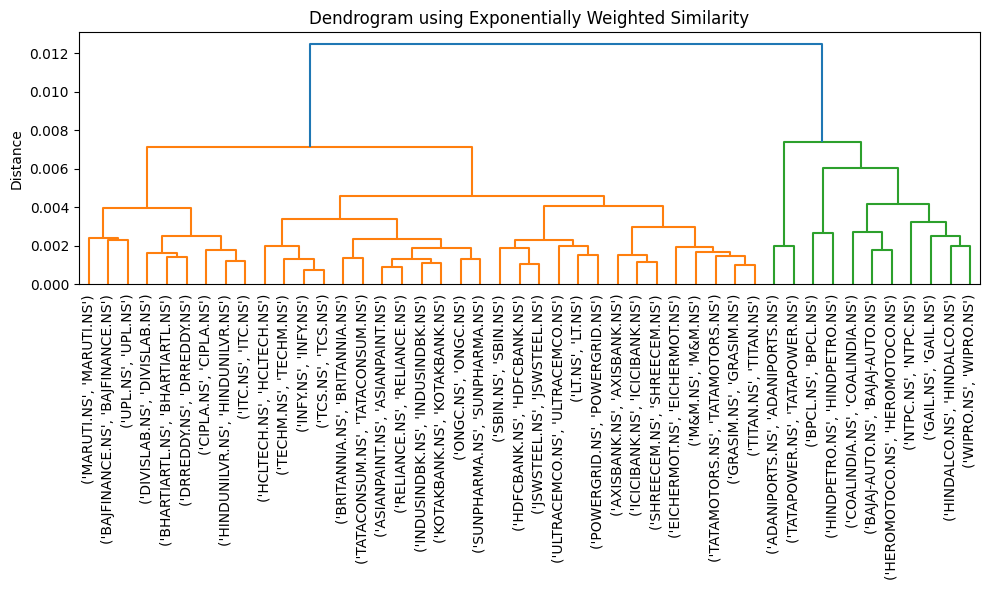

/usr/local/lib/python3.11/dist-packages/scipy/cluster/hierarchy.py:796: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  return linkage(y, method='ward', metric='euclidean')



📦 Cluster assignment for Exponentially Weighted Similarity:
('ADANIPORTS.NS', 'ADANIPORTS.NS') ➤ Cluster 1
('ASIANPAINT.NS', 'ASIANPAINT.NS') ➤ Cluster 0
('AXISBANK.NS', 'AXISBANK.NS') ➤ Cluster 0
('BAJAJ-AUTO.NS', 'BAJAJ-AUTO.NS') ➤ Cluster 2
('BAJFINANCE.NS', 'BAJFINANCE.NS') ➤ Cluster 0
('BHARTIARTL.NS', 'BHARTIARTL.NS') ➤ Cluster 0
('BPCL.NS', 'BPCL.NS') ➤ Cluster 2
('BRITANNIA.NS', 'BRITANNIA.NS') ➤ Cluster 0
('CIPLA.NS', 'CIPLA.NS') ➤ Cluster 0
('COALINDIA.NS', 'COALINDIA.NS') ➤ Cluster 2
('DIVISLAB.NS', 'DIVISLAB.NS') ➤ Cluster 0
('DRREDDY.NS', 'DRREDDY.NS') ➤ Cluster 0
('EICHERMOT.NS', 'EICHERMOT.NS') ➤ Cluster 0
('GAIL.NS', 'GAIL.NS') ➤ Cluster 2
('GRASIM.NS', 'GRASIM.NS') ➤ Cluster 0
('HCLTECH.NS', 'HCLTECH.NS') ➤ Cluster 0
('HDFCBANK.NS', 'HDFCBANK.NS') ➤ Cluster 0
('HEROMOTOCO.NS', 'HEROMOTOCO.NS') ➤ Cluster 2
('HINDALCO.NS', 'HINDALCO.NS') ➤ Cluster 2
('HINDPETRO.NS', 'HINDPETRO.NS') ➤ Cluster 1
('HINDUNILVR.NS', 'HINDUNILVR.NS') ➤ Cluster 0
('ICICIBANK.NS', 'ICICIBANK.NS

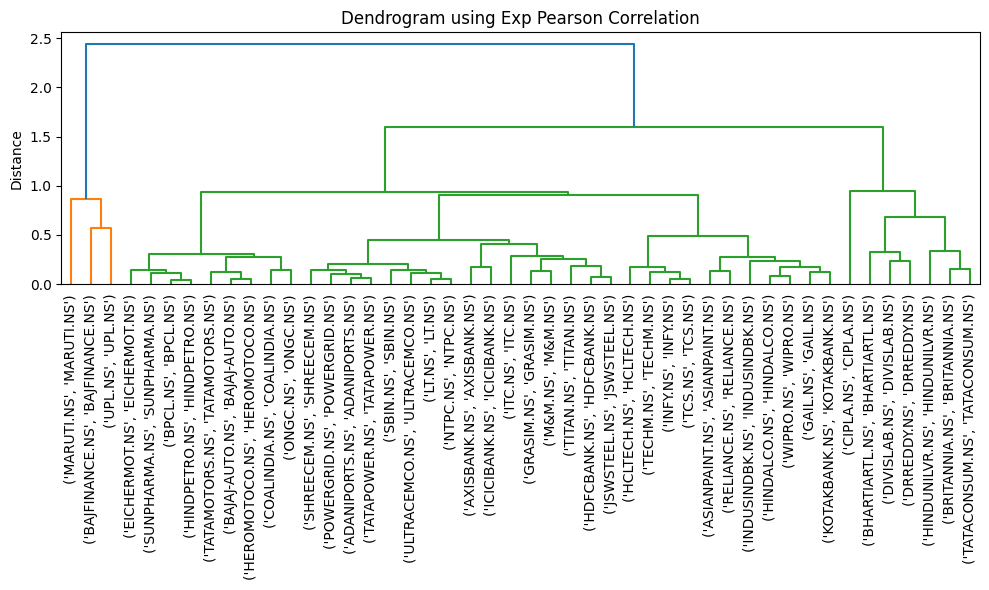


📦 Cluster assignment for Exp Pearson Correlation:
('ADANIPORTS.NS', 'ADANIPORTS.NS') ➤ Cluster 0
('ASIANPAINT.NS', 'ASIANPAINT.NS') ➤ Cluster 0
('AXISBANK.NS', 'AXISBANK.NS') ➤ Cluster 0
('BAJAJ-AUTO.NS', 'BAJAJ-AUTO.NS') ➤ Cluster 0
('BAJFINANCE.NS', 'BAJFINANCE.NS') ➤ Cluster 1
('BHARTIARTL.NS', 'BHARTIARTL.NS') ➤ Cluster 0
('BPCL.NS', 'BPCL.NS') ➤ Cluster 0
('BRITANNIA.NS', 'BRITANNIA.NS') ➤ Cluster 0
('CIPLA.NS', 'CIPLA.NS') ➤ Cluster 2
('COALINDIA.NS', 'COALINDIA.NS') ➤ Cluster 0
('DIVISLAB.NS', 'DIVISLAB.NS') ➤ Cluster 2
('DRREDDY.NS', 'DRREDDY.NS') ➤ Cluster 2
('EICHERMOT.NS', 'EICHERMOT.NS') ➤ Cluster 0
('GAIL.NS', 'GAIL.NS') ➤ Cluster 0
('GRASIM.NS', 'GRASIM.NS') ➤ Cluster 0
('HCLTECH.NS', 'HCLTECH.NS') ➤ Cluster 0
('HDFCBANK.NS', 'HDFCBANK.NS') ➤ Cluster 0
('HEROMOTOCO.NS', 'HEROMOTOCO.NS') ➤ Cluster 0
('HINDALCO.NS', 'HINDALCO.NS') ➤ Cluster 0
('HINDPETRO.NS', 'HINDPETRO.NS') ➤ Cluster 0
('HINDUNILVR.NS', 'HINDUNILVR.NS') ➤ Cluster 2
('ICICIBANK.NS', 'ICICIBANK.NS') ➤ Clust

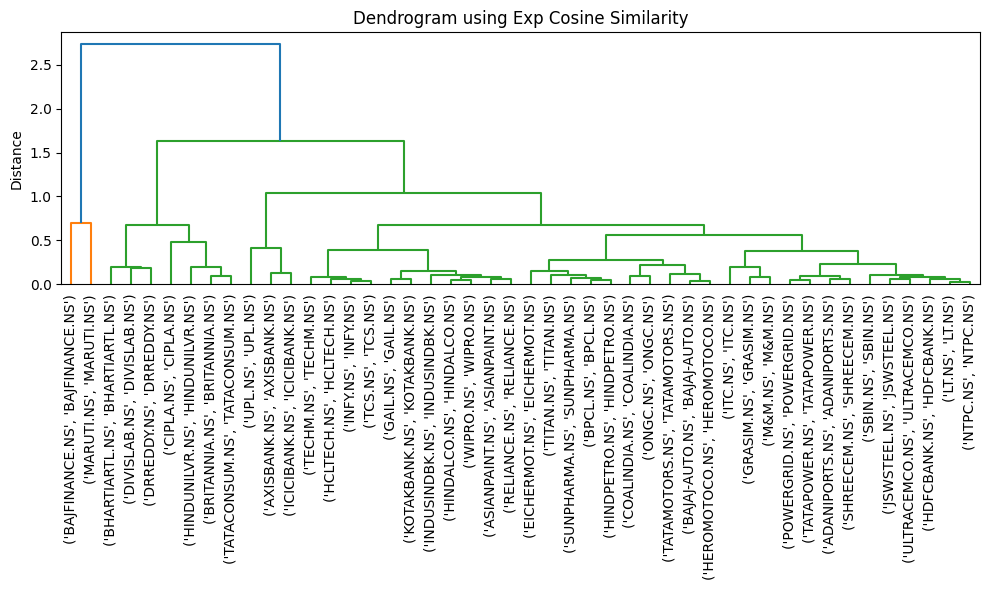


📦 Cluster assignment for Exp Cosine Similarity:
('ADANIPORTS.NS', 'ADANIPORTS.NS') ➤ Cluster 2
('ASIANPAINT.NS', 'ASIANPAINT.NS') ➤ Cluster 2
('AXISBANK.NS', 'AXISBANK.NS') ➤ Cluster 0
('BAJAJ-AUTO.NS', 'BAJAJ-AUTO.NS') ➤ Cluster 2
('BAJFINANCE.NS', 'BAJFINANCE.NS') ➤ Cluster 1
('BHARTIARTL.NS', 'BHARTIARTL.NS') ➤ Cluster 0
('BPCL.NS', 'BPCL.NS') ➤ Cluster 2
('BRITANNIA.NS', 'BRITANNIA.NS') ➤ Cluster 2
('CIPLA.NS', 'CIPLA.NS') ➤ Cluster 0
('COALINDIA.NS', 'COALINDIA.NS') ➤ Cluster 2
('DIVISLAB.NS', 'DIVISLAB.NS') ➤ Cluster 0
('DRREDDY.NS', 'DRREDDY.NS') ➤ Cluster 0
('EICHERMOT.NS', 'EICHERMOT.NS') ➤ Cluster 2
('GAIL.NS', 'GAIL.NS') ➤ Cluster 2
('GRASIM.NS', 'GRASIM.NS') ➤ Cluster 2
('HCLTECH.NS', 'HCLTECH.NS') ➤ Cluster 2
('HDFCBANK.NS', 'HDFCBANK.NS') ➤ Cluster 2
('HEROMOTOCO.NS', 'HEROMOTOCO.NS') ➤ Cluster 2
('HINDALCO.NS', 'HINDALCO.NS') ➤ Cluster 2
('HINDPETRO.NS', 'HINDPETRO.NS') ➤ Cluster 2
('HINDUNILVR.NS', 'HINDUNILVR.NS') ➤ Cluster 0
('ICICIBANK.NS', 'ICICIBANK.NS') ➤ Cluster

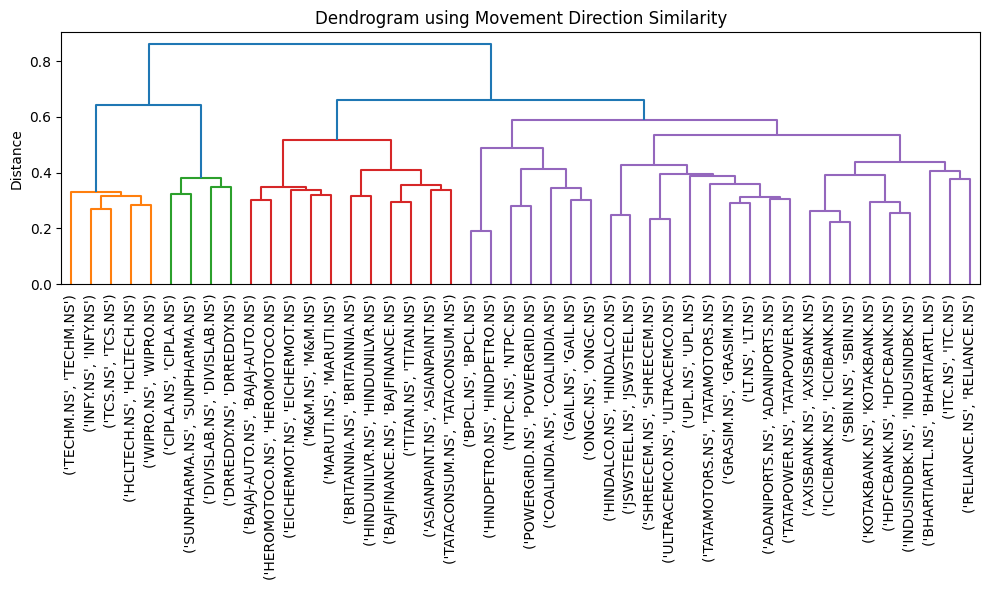

/usr/local/lib/python3.11/dist-packages/scipy/cluster/hierarchy.py:796: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  return linkage(y, method='ward', metric='euclidean')



📦 Cluster assignment for Movement Direction Similarity:
('ADANIPORTS.NS', 'ADANIPORTS.NS') ➤ Cluster 0
('ASIANPAINT.NS', 'ASIANPAINT.NS') ➤ Cluster 2
('AXISBANK.NS', 'AXISBANK.NS') ➤ Cluster 0
('BAJAJ-AUTO.NS', 'BAJAJ-AUTO.NS') ➤ Cluster 2
('BAJFINANCE.NS', 'BAJFINANCE.NS') ➤ Cluster 2
('BHARTIARTL.NS', 'BHARTIARTL.NS') ➤ Cluster 2
('BPCL.NS', 'BPCL.NS') ➤ Cluster 0
('BRITANNIA.NS', 'BRITANNIA.NS') ➤ Cluster 2
('CIPLA.NS', 'CIPLA.NS') ➤ Cluster 1
('COALINDIA.NS', 'COALINDIA.NS') ➤ Cluster 0
('DIVISLAB.NS', 'DIVISLAB.NS') ➤ Cluster 1
('DRREDDY.NS', 'DRREDDY.NS') ➤ Cluster 1
('EICHERMOT.NS', 'EICHERMOT.NS') ➤ Cluster 2
('GAIL.NS', 'GAIL.NS') ➤ Cluster 0
('GRASIM.NS', 'GRASIM.NS') ➤ Cluster 0
('HCLTECH.NS', 'HCLTECH.NS') ➤ Cluster 1
('HDFCBANK.NS', 'HDFCBANK.NS') ➤ Cluster 2
('HEROMOTOCO.NS', 'HEROMOTOCO.NS') ➤ Cluster 2
('HINDALCO.NS', 'HINDALCO.NS') ➤ Cluster 0
('HINDPETRO.NS', 'HINDPETRO.NS') ➤ Cluster 0
('HINDUNILVR.NS', 'HINDUNILVR.NS') ➤ Cluster 2
('ICICIBANK.NS', 'ICICIBANK.NS') ➤

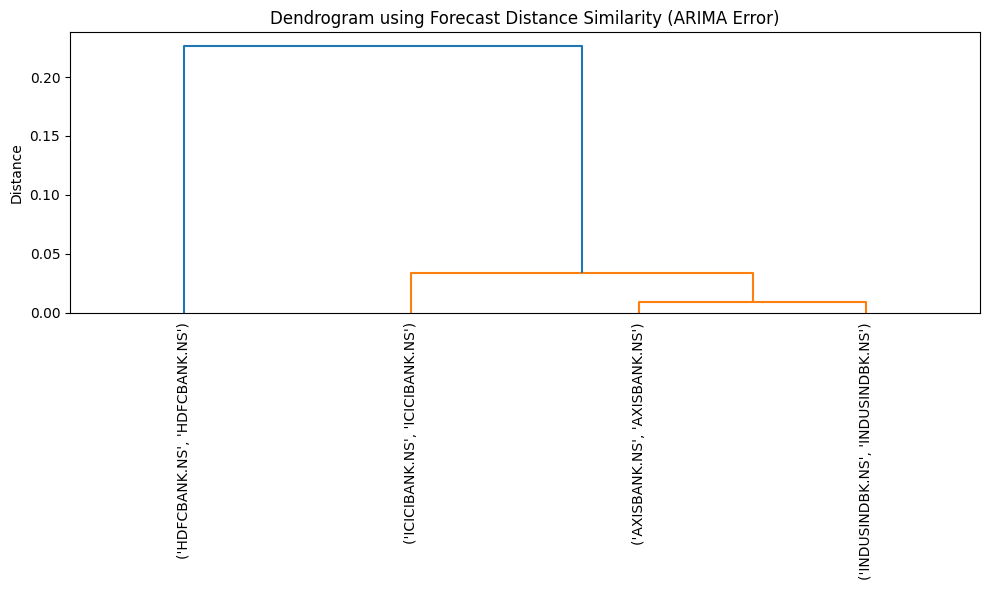


📦 Cluster assignment for Forecast Distance Similarity (ARIMA Error):
('AXISBANK.NS', 'AXISBANK.NS') ➤ Cluster 0
('HDFCBANK.NS', 'HDFCBANK.NS') ➤ Cluster 1
('ICICIBANK.NS', 'ICICIBANK.NS') ➤ Cluster 2
('INDUSINDBK.NS', 'INDUSINDBK.NS') ➤ Cluster 0


/usr/local/lib/python3.11/dist-packages/scipy/cluster/hierarchy.py:796: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  return linkage(y, method='ward', metric='euclidean')


NameError: name 'coint_sim_matrix' is not defined

In [ ]:

#Run clustering on each similarity metric
cluster_and_plot(exp_sim_matrix, method_name="Exponentially Weighted Similarity")
cluster_and_plot(exp_pearson, method_name="Exp Pearson Correlation")
cluster_and_plot(exp_cosine, method_name="Exp Cosine Similarity")
# cluster_and_plot(gaussian_sim, method_name="Gaussian Similarity")
cluster_and_plot(movement_sim, method_name="Movement Direction Similarity")
cluster_and_plot(forecast_sim, method_name="Forecast Distance Similarity (ARIMA Error)")
# cluster_and_plot(rolling_cosine, method_name="Rolling Cosine Similarity")
# cluster_and_plot(tsfresh_cosine, method_name="TSFresh + Cosine Similarity")
# cluster_and_plot(tsfresh_dtw, method_name="TSFresh + DTW Similarity")
# cluster_and_plot(dtw_similarity_matrix, method_name="Pure DTW Similarity")
# cluster_and_plot(dtw_sim_matrix, method_name="DTW Similarity")
# cluster_and_plot(coint_sim_matrix, method_name="Cointegration Similarity")

In [ ]:
 import pandas as pd, numpy as np, seaborn as sns
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Seaborn:", sns.__version__)


Pandas: 2.2.2
NumPy: 2.0.2
Seaborn: 0.13.2


In [ ]:
from sklearn.decomposition import PCA
from sklearn.manifold import SpectralEmbedding, MDS
import pandas as pd
import numpy as np

# Precomputed movement similarity matrix (correlation-based)
# Ensure movement_sim is defined outside this script
distance_matrix = 1 - movement_sim.fillna(0)
stock_names = distance_matrix.index

# Loop through dimensions
for dim in range(4, 37, 4):
    embedding_columns = [f"embed_{i+1}" for i in range(dim)]

    # PCA
    pca = PCA(n_components=dim)
    embeddings_pca = pca.fit_transform(distance_matrix)
    df_pca = pd.DataFrame(embeddings_pca, index=stock_names, columns=embedding_columns)
    df_pca.reset_index(inplace=True)
    df_pca.rename(columns={"index": "Ticker"}, inplace=True)
    df_pca.to_csv(f"stock_embeddings_pca_{dim}.csv", index=False)

    # Spectral Embedding (uses similarity matrix directly)
    spectral = SpectralEmbedding(n_components=dim, affinity='precomputed', random_state=42)
    try:
        embeddings_spec = spectral.fit_transform(movement_sim.fillna(0))
        df_spec = pd.DataFrame(embeddings_spec, index=stock_names, columns=embedding_columns)
        df_spec.reset_index(inplace=True)
        df_spec.rename(columns={"index": "Ticker"}, inplace=True)
        df_spec.to_csv(f"stock_embeddings_spectral_{dim}.csv", index=False)
    except Exception as e:
        print(f"Spectral failed for dim {dim}: {e}")

    # MDS
    mds = MDS(n_components=dim, dissimilarity='precomputed', random_state=42, n_init=4, max_iter=300)
    try:
        embeddings_mds = mds.fit_transform(distance_matrix)
        df_mds = pd.DataFrame(embeddings_mds, index=stock_names, columns=embedding_columns)
        df_mds.reset_index(inplace=True)
        df_mds.rename(columns={"index": "Ticker"}, inplace=True)
        df_mds.to_csv(f"stock_embeddings_mds_{dim}.csv", index=False)
    except Exception as e:
        print(f"MDS failed for dim {dim}: {e}")
